# 04. Long-run balance decomposition

Read the canonical decomposition over 1977-2025, identify the years with a positive aggregate balance, and quantify the Social Security offset metrics as accounting ratios.

**Reads**

- `data/processed/annual_balance_metrics_1977_2025.csv`
- `outputs/metrics/analysis_summary.json`

**Writes**

- Nothing. All metrics shown here are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 5

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. The panel

`annual_balance_metrics_1977_2025.csv` is the canonical balance panel plus derived
offset and contribution metrics. Every column is calculated; none is transcribed.

In [2]:
annual = pd.read_csv(PROCESSED / 'annual_balance_metrics_1977_2025.csv')
levels = [
    'year',
    'general_government_balance_m_eur',
    'central_government_balance_m_eur',
    'regional_local_balance_m_eur',
    'social_security_balance_m_eur',
    'non_ssf_balance_m_eur',
    'ssf_offset_ratio',
]
print('years:', int(annual['year'].min()), 'to', int(annual['year'].max()), f'({len(annual)} observations)')
display(annual[levels].tail(12).round(3))

years: 1977 to 2025 (49 observations)


,year,general_government_balance_m_eur,central_government_balance_m_eur,regional_local_balance_m_eur,social_security_balance_m_eur,non_ssf_balance_m_eur,ssf_offset_ratio
37,2014,-12752.0,-14214.0,655.0,808.0,-13559.0,0.060
38,2015,-8026.0,-9931.0,776.0,1129.0,-9155.0,0.123
39,2016,-3622.0,-6055.0,863.0,1570.0,-5192.0,0.302
40,2017,-5870.0,-8460.0,348.0,2243.0,-8112.0,0.277
41,2018,-873.0,-3407.0,499.0,2035.0,-2908.0,0.700
42,2019,249.0,-3331.0,604.0,2975.0,-2727.0,1.091
43,2020,-11564.0,-13555.0,-207.0,2198.0,-13762.0,0.160
44,2021,-6117.0,-7985.0,-601.0,2468.0,-8586.0,0.287
45,2022,-757.0,-4966.0,-91.0,4299.0,-5057.0,0.850
46,2023,3030.0,-2447.0,-243.0,5720.0,-2690.0,2.126


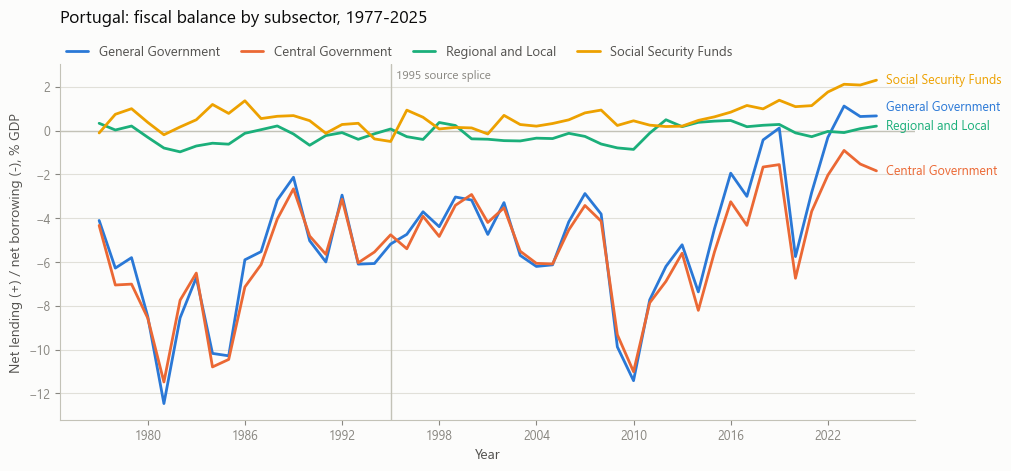

In [3]:
figure = figures.balances_by_subsector(annual)

## 2. Contributions to the aggregate

The stacked columns below are the three subsector balances; their signed sum is
the General Government line. The chart is the identity drawn, so a tall column
under a shallow line means the subsectors offset one another that year.

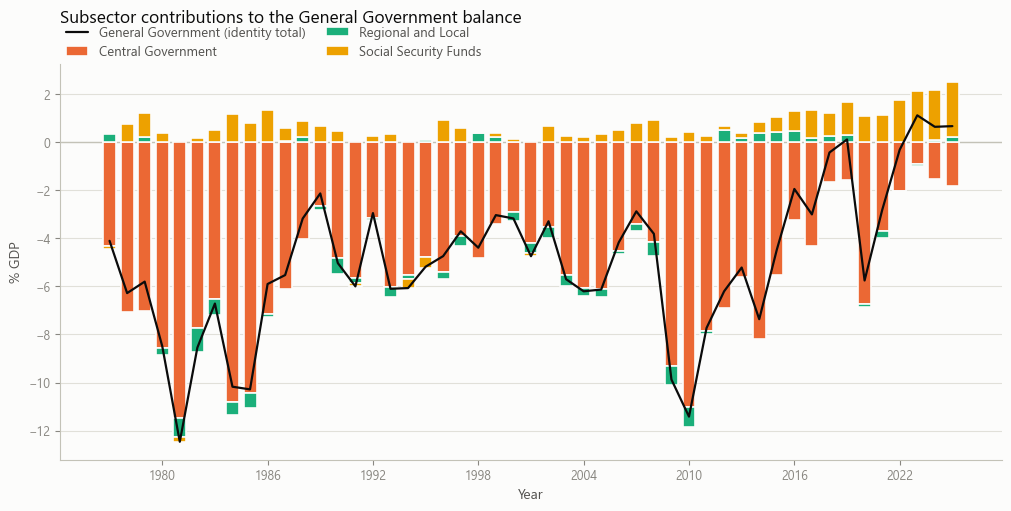

In [4]:
figure = figures.subsector_contributions(annual)

## 3. Positive aggregate-balance years

$$B^{nonSSF}_t = B^{C}_t + B^{RL}_t$$

and, when $B^{nonSSF}_t < 0$ and $B^{SSF}_t > 0$, the offset ratio is

$$O_t = \frac{B^{SSF}_t}{\left|B^{nonSSF}_t\right|}.$$

$O_t = 1$ means the positive Social Security balance is exactly the size of the
negative non-SSF balance. The ratio is an accounting comparison of two recorded
numbers. It is not a counterfactual, and it does not describe what either balance
would be under different institutional arrangements.

In [5]:
positive = annual.loc[
    annual['aggregate_balance_positive'],
    [
        'year',
        'general_government_balance_m_eur',
        'non_ssf_balance_m_eur',
        'social_security_balance_m_eur',
        'ssf_offset_ratio',
        'ssf_share_of_positive_aggregate_balance',
    ],
]
display(positive.round(3))
print('years with a positive aggregate balance:', [int(year) for year in positive['year']])

,year,general_government_balance_m_eur,non_ssf_balance_m_eur,social_security_balance_m_eur,ssf_offset_ratio,ssf_share_of_positive_aggregate_balance
42,2019,249.0,-2727.0,2975.0,1.091,11.948
46,2023,3030.0,-2690.0,5720.0,2.126,1.888
47,2024,1863.0,-4168.0,6031.0,1.447,3.237
48,2025,2059.0,-5006.0,7065.0,1.411,3.431


years with a positive aggregate balance: [2019, 2023, 2024, 2025]


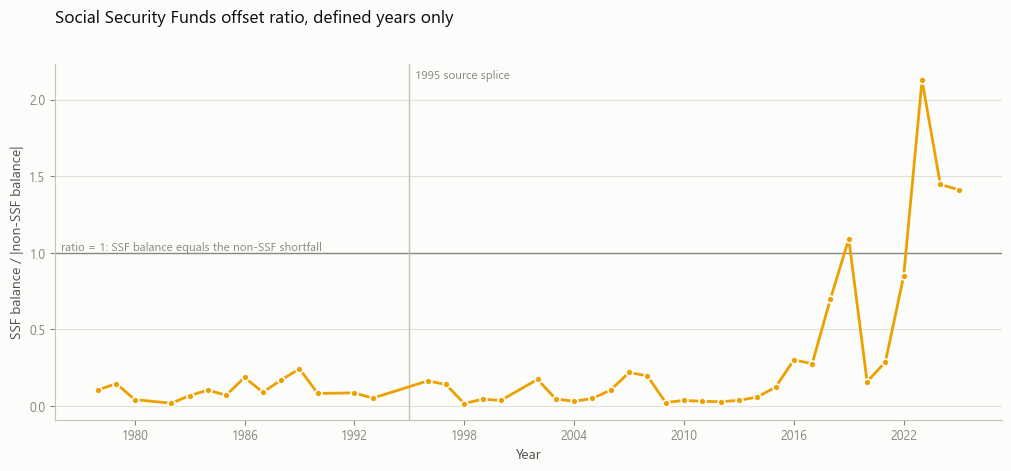

In [6]:
figure = figures.offset_ratio(annual)

## 4. Regime-aware averages

Five-year rolling means are shown because single-year balances are volatile. The
window spans the 1995 splice for the years around it, so those values mix two
statistical vintages and should be read accordingly.

In [7]:
rolling = [
    'year',
    'general_government_balance_5y_mean_pct_gdp',
    'central_government_balance_5y_mean_pct_gdp',
    'regional_local_balance_5y_mean_pct_gdp',
    'social_security_balance_5y_mean_pct_gdp',
]
display(annual[rolling].tail(10).round(3))

,year,general_government_balance_5y_mean_pct_gdp,central_government_balance_5y_mean_pct_gdp,regional_local_balance_5y_mean_pct_gdp,social_security_balance_5y_mean_pct_gdp
39,2016,-5.039,-5.895,0.390,0.466
40,2017,-4.399,-5.383,0.327,0.658
41,2018,-3.442,-4.596,0.339,0.816
42,2019,-1.946,-3.265,0.320,1.000
43,2020,-2.202,-3.507,0.213,1.093
44,2021,-2.378,-3.595,0.064,1.152
45,2022,-1.840,-3.136,0.021,1.275
46,2023,-1.530,-2.985,-0.045,1.500
47,2024,-1.425,-2.980,-0.084,1.638
48,2025,-0.140,-1.999,-0.022,1.880


In [8]:
import json

summary = json.loads((METRICS / 'analysis_summary.json').read_text(encoding='utf-8'))
latest = summary['balance_summary']['latest_year']
print('latest year in the panel:', latest['year'])
display(
    pd.Series({key: value for key, value in latest.items() if key != 'year'}, name=str(latest['year']))
    .to_frame()
    .round(3)
)

latest year in the panel: 2025


,2025
central_government_balance_m_eur,-5636.000
general_government_balance_m_eur,2059.000
non_ssf_balance_m_eur,-5006.000
regional_local_balance_m_eur,630.000
social_security_balance_m_eur,7065.000
ssf_offset_ratio,1.411


## Interpretation limits

1. The offset ratio is **defined only** when the non-SSF balance is negative and
   the Social Security balance is positive. It is `NaN` otherwise, by design.
2. A subsector's arithmetic contribution to a positive aggregate balance is
   **not evidence of causation** and not a statement about policy intent.
3. The 1977-1994 and 1995-2025 segments come from **different statistical
   vintages**. Long-run comparisons carry that caveat throughout.

---

[Previous: 03. Harmonisation and validation](03_harmonize_and_validate.ipynb) | [Next: 05. Revenue and expenditure decomposition](05_revenue_expenditure.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```